<a href="https://colab.research.google.com/github/jaydenjung-bohs09/jaydenjung-bohs09.github.io/blob/main/genmol_leadopt_your_predictor_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=darkblue> **GenMol: goal-directed lead optimization with your own affinity predictor** </font>

This notebook reproduces **Section 5.4 (Goal-Directed Lead Optimization)** from the **GenMol** paper
([arXiv:2501.06158](https://arxiv.org/abs/2501.06158), ICML 2025), with one substitution: the paper's QuickVina2 docking oracle is replaced by **a binding-affinity model you supply**.

Use the companion notebook `genmol_lead_optimization_docking_colab.ipynb` if you would rather run the paper's original docking objective, against either its five packaged targets or a custom protein of your own.

### <font color=darkblue> What changes when the oracle is a learned model </font>

Structurally, nothing. The optimizer only ever calls `oracle.score(smiles_list)` and expects higher to mean better binding, so a docking program and a neural network are interchangeable at that interface. Two practical differences are worth stating up front.

First, **cost**. Docking takes seconds per molecule, which is what forces the paper's modest budget of 1000 oracle calls. A learned predictor is typically milliseconds per molecule, so you can afford far more iterations, and iterations are where this method gains most.

Second, **failure mode**. Docking is a physical model that is wrong in physically interpretable ways. A learned predictor is wrong in whatever way its training distribution allows, and this optimizer is an unconstrained search for inputs that maximize it. Expect it to find your model's blind spots. The Notes at the end discuss how to guard against that.

> Set the runtime to GPU (Runtime > Change runtime type) for GenMol. Your predictor may or may not need one.

## <font color=darkblue> **1. Install** </font>

In [ ]:
#@title Install dependencies  (this cell RESTARTS the runtime once, and it is expected)
import os, sys, subprocess

# GenMol is built against numpy 1.26.4, but Colab preloads numpy 2.x. Mixing the two gives
#   "ValueError: numpy.dtype size changed ..." at `import safe`.
# Fix = install the pinned stack, then RESTART so the old numpy C-extension is unloaded.
SENTINEL = '/content/.genmol_installed'

if os.path.exists(SENTINEL):
    print('Dependencies already installed - skipping (delete %s to force a reinstall).' % SENTINEL)
else:
    pkgs = ['numpy==1.26.4', 'safe-mol==0.1.14', 'bionemo-moco==0.0.2.1', 'lightning>=2.4', 'transformers>=4.44,<5', 'hydra-core==1.3.2', 'omegaconf==2.3.0', 'easydict', 'rdkit', 'huggingface_hub', 'openbabel-wheel']
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)
    open(SENTINEL, 'w').close()
    print('\n' + '=' * 68)
    print(' Dependencies installed. RESTARTING the runtime now (this is expected).')
    print(' When it reconnects, just run this cell again - it will skip - and')
    print(' continue with the cells below.')
    print('=' * 68)
    os.kill(os.getpid(), 9)   # hard restart; the only reliable way to reload numpy on Colab

Dependencies already installed - skipping (delete /content/.genmol_installed to force a reinstall).


In [ ]:
#@title <font color=darkblue> Clone GenMol and download the pretrained V1 checkpoint </font>
import os, subprocess, sys

if not os.path.exists('/content/genmol'):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/NVIDIA-BioNeMo/genmol.git', '/content/genmol'], check=True)
os.chdir('/content/genmol')

# install the package itself without touching the dependency graph we pinned above
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--no-deps', '-e', '.'], check=True)

# GenMol V1 checkpoint (ungated, 89M params, ~1 GB)
from huggingface_hub import hf_hub_download
CKPT = hf_hub_download('nvidia/NV-GenMol-89M-v1', 'model.ckpt')
print('checkpoint:', CKPT)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.ckpt:   0%|          | 0.00/1.40G [00:00<?, ?B/s]

checkpoint: /root/.cache/huggingface/hub/models--nvidia--NV-GenMol-89M-v1/snapshots/cdaf0c1b45c281315ab10389836bc46093cdbb65/model.ckpt


## <font color=darkblue> **1b. Mount Google Drive** </font>

We keep inputs and outputs on Google Drive so they survive a runtime restart. Put any custom-target files (a receptor `.pdb` or `.pdbqt`, and optionally a reference ligand) under the `inputs` folder; every run writes its guidance trajectory, leads, and config under `outputs`. Running the cell prompts you to authorize Drive access. `RUN_NAME` namespaces the outputs so successive runs do not overwrite each other.

In [ ]:
#@title <font color=darkblue> Mount Drive and set input/output folders </font>
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/genmol_lead_opt'   #@param {type:'string'}
RUN_NAME  = 'run1'                                     #@param {type:'string'}
INPUT_DIR  = os.path.join(DRIVE_DIR, 'inputs')
OUTPUT_DIR = os.path.join(DRIVE_DIR, 'outputs')
os.makedirs(INPUT_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def out_path(suffix):
    '''Drive output path, namespaced by RUN_NAME so runs do not overwrite each other.'''
    return os.path.join(OUTPUT_DIR, f'{RUN_NAME}_{suffix}')

print('inputs  :', INPUT_DIR)
print('outputs :', OUTPUT_DIR)

Mounted at /content/drive
inputs  : /content/drive/MyDrive/genmol_lead_opt/inputs
outputs : /content/drive/MyDrive/genmol_lead_opt/outputs


In [ ]:
#@title <font color=darkblue> Import GenMol </font>
import sys, os

# GenMol was installed with `pip install -e .`, whose setuptools editable finder exposes the
# top-level `genmol` package but not its subpackages (genmol.utils, genmol.sampler). Drop that
# finder, clear any half-imported genmol, and import straight from src/ instead.
sys.meta_path = [f for f in sys.meta_path if 'genmol' not in repr(f).lower()]
for m in [k for k in list(sys.modules) if k == 'genmol' or k.startswith('genmol.')]:
    del sys.modules[m]

sys.path.insert(0, '/content/genmol/src')   # genmol package (src-layout)
sys.path.insert(0, '/content/genmol')       # repo root, for `scripts...` imports

import safe as sf                            # numpy is already fixed by the install cell
import genmol
print('genmol ->', genmol.__file__)          # expect /content/genmol/src/genmol/__init__.py
from genmol.sampler import Sampler
from genmol.utils.utils_chem import cut
print('GenMol imported OK')

🚨 `inputs` is part of SAFEDoubleHeadsModel.forward's signature, but not documented. Make sure to add it to the docstring of the function in /usr/local/lib/python3.12/dist-packages/safe/trainer/model.py.
genmol -> /content/genmol/src/genmol/__init__.py
GenMol imported OK


In [ ]:
#@title <font color=darkblue> Load the model onto the GPU </font>
import torch
import torch.serialization as _ts

# PyTorch 2.6 + Lightning 2.5 pass weights_only=True to torch.load, which rejects the omegaconf
# config pickled inside GenMol's (trusted) checkpoint. Force weights_only=False through the pristine
# loader. Referencing _ts.load (never reassigned) keeps this safe to re-run, no self-recursion.
def _load(*a, **k):
    k['weights_only'] = False
    return _ts.load(*a, **k)

torch.load = _load
sampler = Sampler(CKPT)
torch.load = _ts.load                        # restore pristine default

device = 'cuda' if torch.cuda.is_available() else 'cpu'
sampler.model.to(device)
sampler.mdlm.to_device(sampler.model.device)  # MDLM caches its own device handle
print('device:', sampler.model.device)

# smoke test: fragment-remask an aspirin-like molecule
print(sampler.mask_modification('CC(=O)Oc1ccccc1C(=O)O', min_len=50, gamma=0))

tokenizer.json: 0.00B [00:00, ?B/s]

device: cuda:0
CC(=O)Oc1c(NC(=O)CCc2cnn(C)c2)cccc1C(=O)O


### <font color=darkblue> What model did we just load? </font>

A quick tour of the thing `Sampler(CKPT)` just put on the GPU, so the generation steps later make sense.
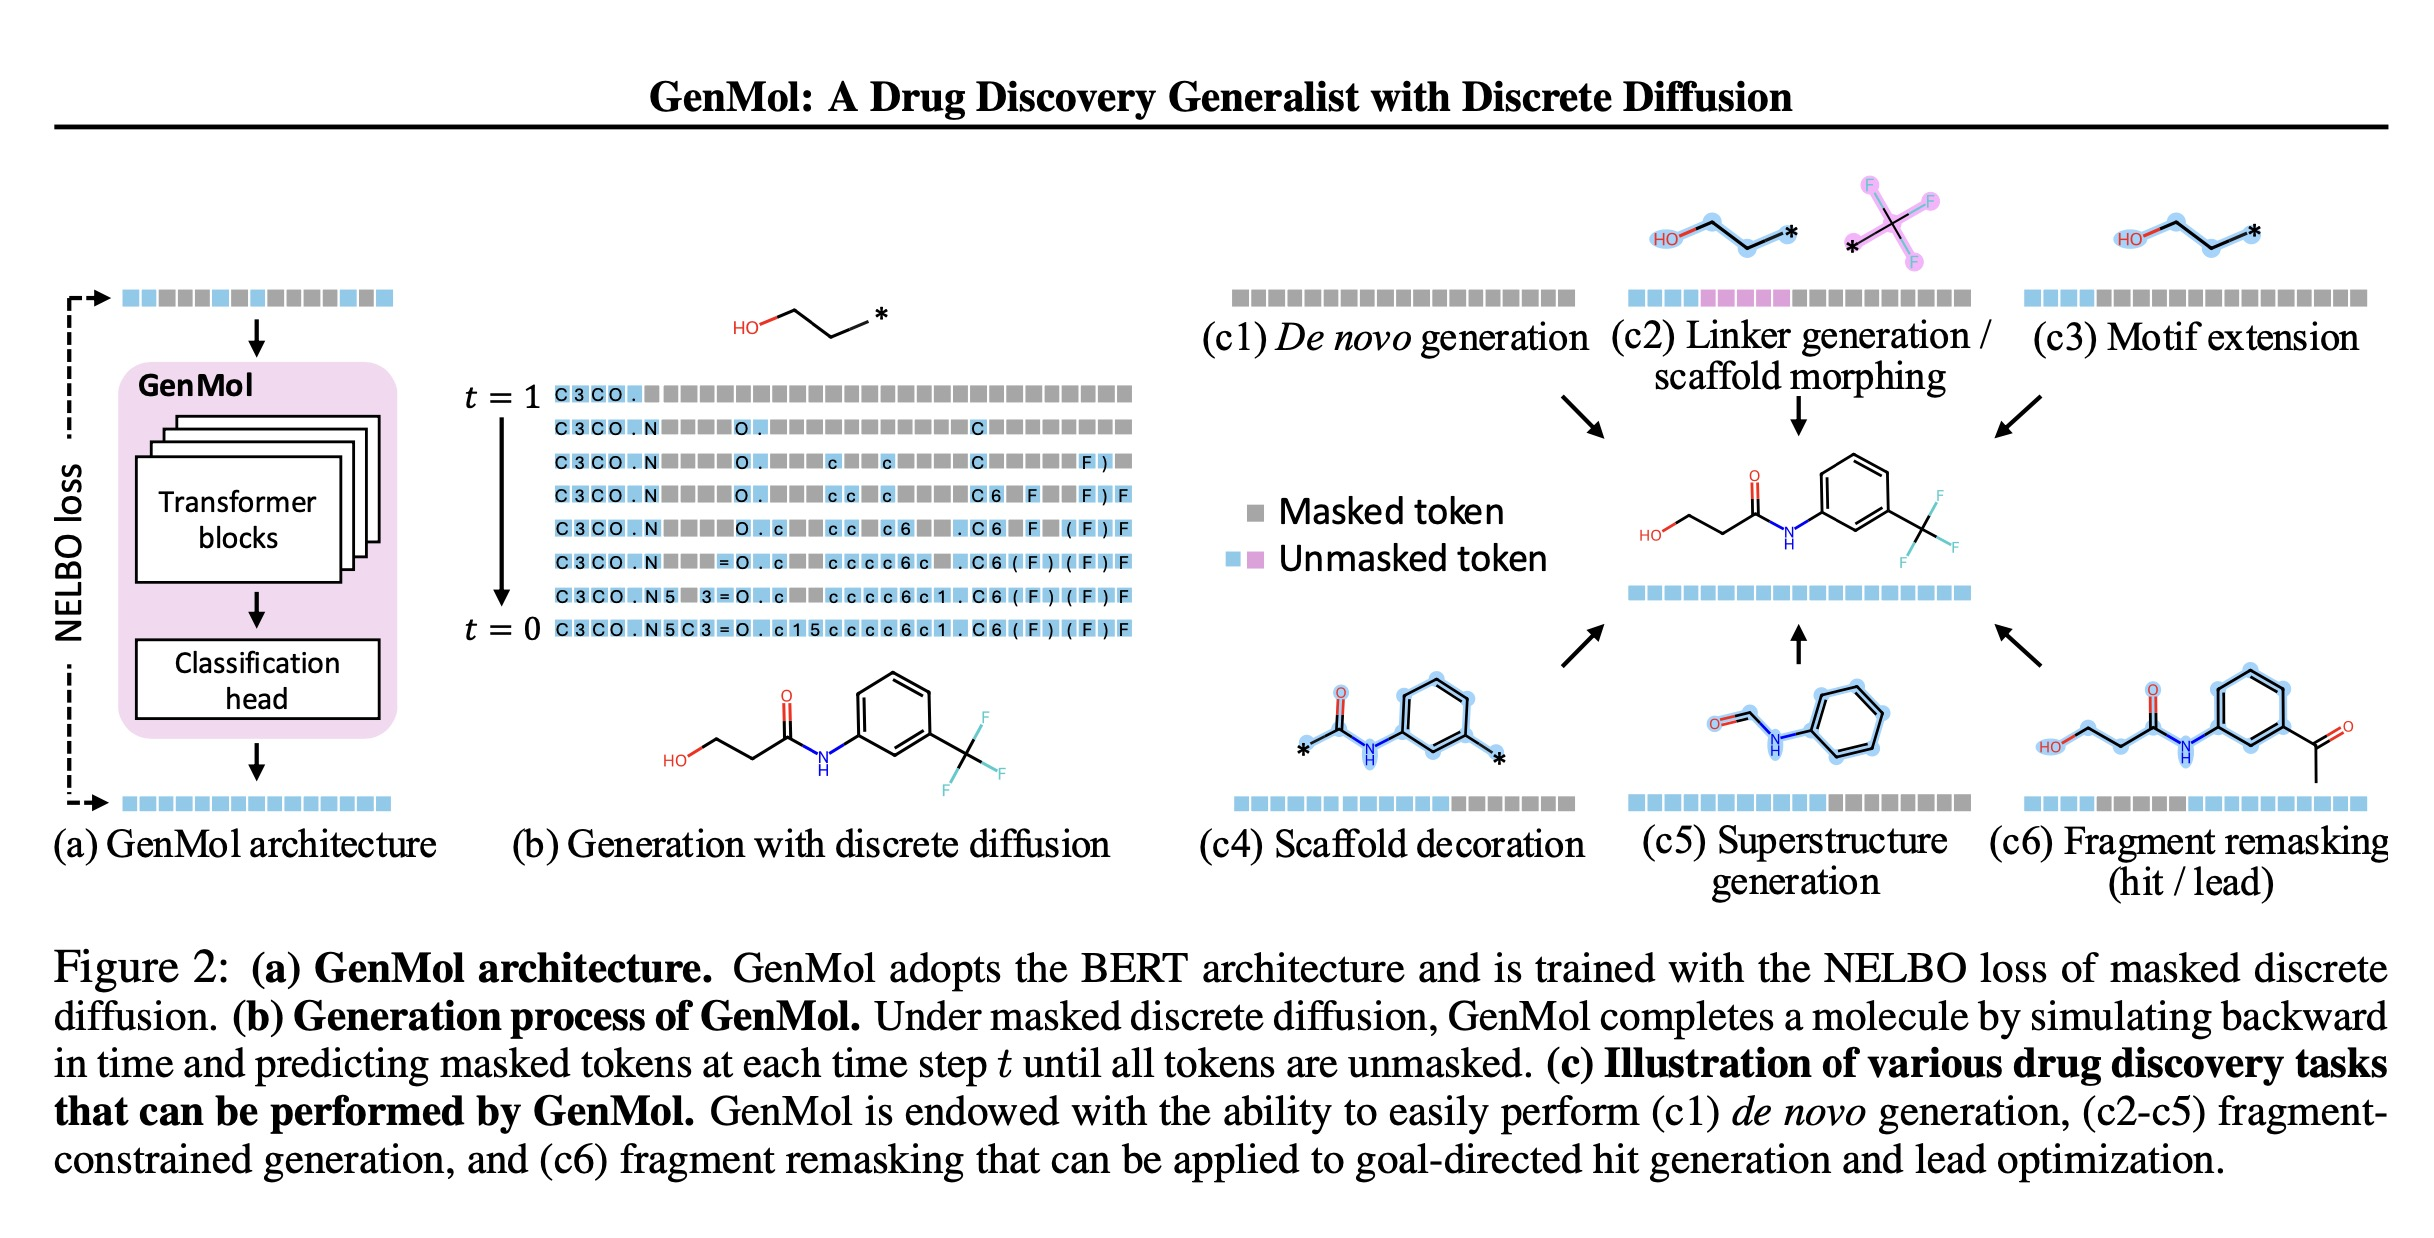

**Backbone.** GenMol is a plain **BERT** encoder (HuggingFace's `BertForMaskedLM`), not a GPT-style autoregressive model. That choice matters: because it's **bidirectional**, it fills in masked tokens by looking at the whole sequence at once, left and right context together, which is exactly what you want when you're regenerating a fragment sitting in the middle of a molecule. It's about 89M parameters:

- 12 transformer layers, hidden size 768, 12 attention heads, feed forward size 3072 (the standard
  BERT base shape)
- a vocabulary of 1880 SAFE tokens, and a maximum sequence length of 256 tokens

**Training objective.** It's trained as a **masked discrete diffusion model** (the paper's MDLM). Instead of predicting the next token, training corrupts a SAFE sequence by replacing a time-dependent fraction of its tokens with a special `[MASK]` token (more masking at higher noise levels), and the model learns to
recover the originals. Sampling runs this in reverse: start from masked positions and iteratively unmask, a few tokens at a time, using the model's own confidence to decide which positions to fill first. A forward pass is just `backbone(x)['logits']`, a distribution over the 1880-token vocab at every position.

**Why this design.** Because decoding is non-autoregressive (parallel unmasking rather than one token at a time), the same single model covers de novo generation, linker design, scaffold decoration, and the fragment remasking we rely on here, all by choosing which positions to mask. There are no task-specific
heads and no fine-tuning.

The code, if you want it: `GenMol` in `src/genmol/model.py` (the `BertForMaskedLM` backbone plus the `MDLM` object), with the exact layer shapes in `configs/base.yaml`.

## <font color=darkblue> **2. Set up Objective** </font>

This is the one section you must edit. Implement `score(smiles_list) -> np.ndarray` on `AffinityOracle`, following the convention **higher means better binding**.

- If your model predicts **pIC50, pKd, or pKi**, return it directly.
- If it predicts a **docking score or binding free energy**, where more negative is better, return the **negation**. This is exactly what the paper does: `GenMolOpt.reward_vina` computes `clip(-docking_score, 0, inf)`.

Two requirements the optimizer relies on. The method must be **batched**, since it is called with `num_gen` SMILES at once, and it must be **robust**: return a very low score rather than raising for anything your featurizer cannot handle. Molecules produced by fragment remasking are occasionally unusual, and one exception will halt an entire run.

A `_DemoOracle` is wired in by default so the notebook runs end to end before you write anything. It is a smooth function of molecular descriptors, not an affinity model, and exists only to exercise the pipeline. Swap it for `AffinityOracle()` once yours is implemented.

The cell also sets `SEED_SMILES`, the starting molecule for lead optimization. Everything downstream reads only `oracle` and `seed_smiles`, so those two objects are the entire interface between this section and the rest of the notebook.

In [ ]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 74.9 MB/s eta 0:00:00


In [ ]:
#@title <font color=darkblue> PLAPT affinity predictor </font>

import os
import sys
import io
import contextlib
import importlib.util
import numpy as np
import torch
from rdkit import Chem
from huggingface_hub import hf_hub_download

#@markdown Starting molecule for lead optimization:
SEED_SMILES = 'CN(C)Cc3ccc2c(CNC(=O)c1cccn12)c3'  #@param {type:'string'}

#@markdown Target protein amino-acid sequence:
TARGET_PROTEIN_SEQUENCE = 'MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG'  #@param {type:'string'}

#@markdown PLAPT batch size:
PLAPT_BATCH_SIZE = 32  #@param {type:'integer'}


class AffinityOracle:
    """
    PLAPT protein-ligand affinity oracle.

    Contract:
        score(smiles_list) -> np.ndarray[float]

    Higher score means stronger predicted binding.
    Scores are PLAPT-predicted pAffinity:
        pAffinity = -log10(affinity in molar units)
    """

    name = "plapt_v1"

    def __init__(
        self,
        protein_sequence=TARGET_PROTEIN_SEQUENCE,
        batch_size=PLAPT_BATCH_SIZE,
        device=None,
    ):
        self.protein_sequence = self._clean_protein_sequence(
            protein_sequence
        )
        self.batch_size = max(1, int(batch_size))
        self.device = device or (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        if not self.protein_sequence:
            raise ValueError(
                "TARGET_PROTEIN_SEQUENCE cannot be empty."
            )

        repo_id = "Bindwell/PLAPT_V1"
        local_dir = "/content/PLAPT_V1"

        os.makedirs(local_dir, exist_ok=True)

        plapt_file = hf_hub_download(
            repo_id=repo_id,
            filename="plapt.py",
            local_dir=local_dir,
        )

        prediction_model = hf_hub_download(
            repo_id=repo_id,
            filename=(
                "models/"
                "affinity_predictor0734-seed2101.onnx"
            ),
            local_dir=local_dir,
        )

        spec = importlib.util.spec_from_file_location(
            "plapt_v1_module",
            plapt_file,
        )

        if spec is None or spec.loader is None:
            raise ImportError(
                f"Could not import PLAPT from {plapt_file}"
            )

        module = importlib.util.module_from_spec(spec)
        sys.modules["plapt_v1_module"] = module
        spec.loader.exec_module(module)

        Plapt = module.Plapt

        print(
            f"Loading PLAPT on {self.device} "
            f"for a {len(self.protein_sequence)}-residue protein..."
        )

        with contextlib.redirect_stdout(io.StringIO()), \
             contextlib.redirect_stderr(io.StringIO()):

            try:
                self.model = Plapt(
                    prediction_module_path=prediction_model,
                    device=self.device,
                    cache_dir="/content/plapt_embedding_cache",
                    use_tqdm=False,
                )
            except TypeError:
                self.model = Plapt(
                    prediction_module_path=prediction_model,
                    caching=True,
                    device=self.device,
                )

        for attribute in ("prot_encoder", "mol_encoder"):
            encoder = getattr(self.model, attribute, None)
            if encoder is not None and hasattr(encoder, "eval"):
                encoder.eval()

        print("PLAPT affinity oracle ready.")

    @staticmethod
    def _clean_protein_sequence(sequence):
        sequence = str(sequence).upper()
        return "".join(
            amino_acid
            for amino_acid in sequence
            if amino_acid.isalpha()
        )

    @staticmethod
    def _canonicalize_smiles(smiles):
        if not isinstance(smiles, str) or not smiles.strip():
            return None

        molecule = Chem.MolFromSmiles(smiles)

        if molecule is None:
            return None

        return Chem.MolToSmiles(
            molecule,
            canonical=True,
            isomericSmiles=True,
        )

    def _predict_valid_smiles(self, valid_smiles):
        try:
            with contextlib.redirect_stdout(io.StringIO()), \
                 contextlib.redirect_stderr(io.StringIO()):

                predictions = self.model.score_candidates(
                    target_protein=self.protein_sequence,
                    mol_smiles=valid_smiles,
                    mol_batch_size=self.batch_size,
                    affinity_batch_size=self.batch_size,
                )

        except TypeError:
            try:
                with contextlib.redirect_stdout(io.StringIO()), \
                     contextlib.redirect_stderr(io.StringIO()):

                    predictions = self.model.score_candidates(
                        self.protein_sequence,
                        valid_smiles,
                    )

            except AttributeError:
                repeated_proteins = [
                    self.protein_sequence
                    for _ in valid_smiles
                ]

                with contextlib.redirect_stdout(io.StringIO()), \
                     contextlib.redirect_stderr(io.StringIO()):

                    predictions = self.model.predict_affinity(
                        repeated_proteins,
                        valid_smiles,
                    )

        scores = []

        for prediction in predictions:
            if isinstance(prediction, dict):
                if "neg_log10_affinity_M" in prediction:
                    score = prediction[
                        "neg_log10_affinity_M"
                    ]
                elif "pAffinity" in prediction:
                    score = prediction["pAffinity"]
                else:
                    raise KeyError(
                        "PLAPT prediction did not contain a "
                        "recognized affinity field."
                    )
            else:
                score = prediction

            scores.append(float(score))

        return scores

    def score(self, smiles_list):
        if isinstance(smiles_list, str):
            smiles_list = [smiles_list]

        smiles_list = list(smiles_list)

        scores = np.full(
            len(smiles_list),
            -1e9,
            dtype=np.float32,
        )

        valid_indices = []
        valid_smiles = []

        for index, smiles in enumerate(smiles_list):
            canonical_smiles = self._canonicalize_smiles(smiles)

            if canonical_smiles is not None:
                valid_indices.append(index)
                valid_smiles.append(canonical_smiles)

        if not valid_smiles:
            return scores

        try:
            predicted_scores = self._predict_valid_smiles(
                valid_smiles
            )

            if len(predicted_scores) != len(valid_smiles):
                raise RuntimeError(
                    "PLAPT returned an unexpected number of scores."
                )

            for index, predicted_score in zip(
                valid_indices,
                predicted_scores,
            ):
                if np.isfinite(predicted_score):
                    scores[index] = predicted_score

        except Exception as error:
            print(f"PLAPT scoring failed: {error}")

        return scores


affinity_oracle = AffinityOracle()

seed_score = affinity_oracle.score([SEED_SMILES])[0]

print(f"Seed SMILES: {SEED_SMILES}")
print(f"Seed PLAPT pAffinity: {seed_score:.4f}")

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

Loading PLAPT on cuda for a 65-residue protein...


vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

PLAPT affinity oracle ready.
Seed SMILES: CN(C)Cc3ccc2c(CNC(=O)c1cccn12)c3
Seed PLAPT pAffinity: 5.5976


### <font color=darkblue> Constraint scorers </font>

A good docking score on its own isn't enough. We also want molecules that are drug-like, reasonable to
synthesize, and still recognizably related to the seed. These three helpers are a direct port of
`GenMolOpt.reward_qed / reward_sa / reward_sim` (`run.py:73-89`).

A quick glossary, since these terms come up constantly in this field:

- **Morgan fingerprint** (also called ECFP): Many of you have used this in Project 1. This is a way to turn a molecule into a fixed-length bit vector.
  You look at each atom and its neighborhood out to some radius (here radius 2, meaning two bonds out),
  hash each little substructure to a position in a 2048-bit array, and flip that bit on. The result is a
  fixed vector where each bit roughly means "this molecule contains this local fragment." It's the
  standard cheap way to compare molecules by structure.

- **Tanimoto similarity**: Many of you have used this too in Project 1. This is for how we compare two of those fingerprints. It's just the number of bits both
  molecules share divided by the number of bits either one has (intersection over union). It runs from 0
  (no substructures in common) to 1 (identical fingerprints). This is what `reward_sim` uses to measure
  how close a generated molecule is to the seed, and it's what the `sim_thr` gate checks.

- **QED** (Quantitative Estimate of Drug-likeness): a single number from 0 to 1 that rolls up several
  molecular properties (molecular weight, lipophilicity, number of hydrogen-bond donors and acceptors,
  and so on) into one "does this look like an oral drug" score. Higher is more drug-like. The paper
  requires QED >= 0.6.

- **SA score** (Synthetic Accessibility): an estimate from 1 to 10 of how hard a molecule would be to
  actually make in a lab, based on the fragments it contains and how complex its rings and stereocenters
  are. Lower is easier to synthesize. It keeps the optimizer from proposing molecules that score well but
  no chemist could reasonably build.

One quirk worth noticing in the code: the SA term is rescaled as `(10 - SAscore) / 9`, which flips it so
that higher is better and puts it on a 0-to-1 scale. That's why the paper's "SA <= 4" constraint shows
up here as `reward_sa >= 6/9`. Same condition, just a different unit.

In [ ]:
import os, sys
import numpy as np
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, DataStructs, QED, RDConfig
RDLogger.DisableLog('rdApp.*')

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

def morgan_fp(mol):
    return AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)

def reward_qed(mols):
    return np.array([QED.qed(m) for m in mols])

def reward_sa(mols):
    # (10 - SA) / 9 ; >= 6/9 is equivalent to SAscore <= 4
    return np.array([(10 - sascorer.calculateScore(m)) / 9 for m in mols])

def reward_sim(mols, ref_fp):
    return np.array(DataStructs.BulkTanimotoSimilarity(ref_fp, [morgan_fp(m) for m in mols]))

### <font color=darkblue> The optimizer: a genetic algorithm around a frozen model </font>

This cell is the heart of the method, a port of the paper's `GenMolOpt`, which implements **Algorithm 1** of the GenMol paper (Section 4.2, "Exploration in Chemical Space with GenMol").

How do you steer a generator whose forward pass has no notion of binding affinity? GenMol takes none of the usual discrete-diffusion routes. Classifier guidance needs a differentiable predictor that scores noisy, half-masked sequences, which is ill-defined for molecules. Classifier-free guidance needs retraining with the property as a conditioning input, tying you to one objective. Exponential tilting keeps the model frozen but still needs a reward estimate at every denoising step, on incomplete molecules. GenMol sidesteps all three: the model stays fully unconditional, and the steering is lifted out of the sampler up to the level of a population of molecules. The predictor is only ever called on finished molecules and only has to rank them, so it can be any black box, and notably it need not be differentiable.

The optimization is a **genetic algorithm**: the paper describes fragment remasking as "a mutation operation in GA where the mutation is performed at the fragment-level," and frames the loop as Gibbs sampling, repeatedly re-drawing one fragment from `p(f_k | f_\k)` with the rest of the molecule held fixed. Your predictor plays the role of the fitness function. Each round:

1. **Attach (crossover).** Two fragments from the pool are joined with the reaction SMARTS `[*:1]-[1*].[1*]-[*:2]>>[*:1]-[*:2]`, giving `x_init`. Blind to the objective.
2. **Remask (mutation).** One fragment of `x_init` is masked and regenerated by GenMol, giving `x_new`. This is what lets the search reach fragments absent from the starting vocabulary.
3. **Score.** Your predictor, plus QED, SA, and Tanimoto similarity to the seed.
4. **Select and enrich.** A candidate is kept as a lead only if it clears every bar at once: predicted affinity better than the seed, plus the Section 5.4 constraints QED >= 0.6, SA <= 4, and similarity >= `sim_thr`. Surviving leads are chopped back into fragments and returned to the pool.

All the steering lives in steps 3 and 4. Molecules that fail any constraint contribute nothing; those that pass donate their fragments, so substructures that help binding accumulate and recombine in later rounds. A fragment appearing in many leads is added many times and is correspondingly more likely to be drawn again. That feedback loop, selection plus fragment reuse, is what turns a blind generator into a goal-directed one.

Three deliberate departures from upstream are flagged in the code: the oracle swap above; a retry fix, since upstream's `generate()` wraps its body in `for _ in range(1000)` but returns unconditionally on the first pass, so the retry never retries; and a `max_heavy_atoms` cap, since every round attaches fragments and molecules only ever grow. Set the cap to `10**9` for exact upstream behavior. Everything else (`min_len=50`, the acceptance rule, `softmax_temp=1.2`, `randomness=2`) matches the paper.

One note on terminology, since the word guidance is overloaded here. The paper also proposes **molecular context guidance** (MCG, Section 4.3), controlled by `gamma`. That is a separate and optional mechanism with nothing to do with the objective: at each denoising step the model runs twice, once on the real input and once on a copy with a `gamma` fraction of the retained context tokens masked, then extrapolates `logits = w * logits_full + (1 - w) * logits_poor` with `w = 2`. The effect is to sharpen the model's reliance on the fragments being held fixed. It is off by default (`gamma = 0`, the repo default), so the genetic loop above does all the steering.

In [ ]:
import random
from dataclasses import dataclass
from time import time
import pandas as pd

@dataclass
class LeadOptConfig:
    seed_smiles: str = 'CN(C)Cc3ccc2c(CNC(=O)c1cccn12)c3'  # overridden by SEED_SMILES in Section 2
    num_gen: int = 100        # molecules generated per iteration
    num_iter: int = 10        # iterations  -> 1000 oracle calls, the paper's budget
    sim_thr: float = 0.4      # delta in {0.4, 0.6}
    qed_thr: float = 0.6
    sa_thr: float = 6 / 9     # == SAscore <= 4
    gamma: float = 0.0        # molecular context guidance strength (0 = off, as in run.py default)
    min_len: int = 50         # remask below this token length, else add masks
    max_attempts: int = 20    # generation retries per molecule
    max_heavy_atoms: int = 60 # safety valve, not in upstream (see note above)
    seed: int = 0


class GenMolLeadOptimizer:
    ATTACH_RXN = AllChem.ReactionFromSmarts('[*:1]-[1*].[1*]-[*:2]>>[*:1]-[*:2]')

    def __init__(self, sampler, oracle, cfg: LeadOptConfig):
        self.sampler, self.oracle, self.cfg = sampler, oracle, cfg
        random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)

        seed_mol = Chem.MolFromSmiles(cfg.seed_smiles)
        assert seed_mol is not None, 'seed SMILES failed to parse'
        self.seed_fp = morgan_fp(seed_mol)
        self.seed_score = float(oracle.score([cfg.seed_smiles])[0])

        # fragment vocabulary: (affinity of the molecule it came from, fragment SMILES)
        self.population = [(self.seed_score, f) for f in cut(cfg.seed_smiles)]
        self.history = []

        print(f'Seed SMILES : {cfg.seed_smiles}')
        print(f'Seed score  : {self.seed_score:.3f}')
        print(f'Initial vocabulary: {len(self.population)} fragments')

    # --- generation -------------------------------------------------------
    def attach(self, frag1, frag2):
        prods = self.ATTACH_RXN.RunReactants((Chem.MolFromSmiles(frag1), Chem.MolFromSmiles(frag2)))
        if not prods:
            return None
        return prods[np.random.randint(len(prods))][0]

    def generate_one(self):
        frags = [f for _, f in self.population]
        for _ in range(self.cfg.max_attempts):
            if len(frags) < 2:
                return None
            f1, f2 = random.sample(frags, 2)
            try:
                prod = self.attach(f1, f2)
                if prod is None:
                    continue
                smiles = Chem.MolToSmiles(prod)
                if not smiles:
                    continue
                # >>> fragment remasking: the core of GenMol's chemical-space exploration <<<
                out = self.sampler.mask_modification(smiles, min_len=self.cfg.min_len, gamma=self.cfg.gamma)
            except Exception:
                continue
            if not out:
                continue
            out = sorted(out.split('.'), key=len)[-1]      # keep the largest disconnected piece
            m = Chem.MolFromSmiles(out)
            if m is not None and m.GetNumHeavyAtoms() <= self.cfg.max_heavy_atoms:
                return out
        return None

    # --- scoring + selection ---------------------------------------------
    def score_batch(self, smiles_list):
        mols = [Chem.MolFromSmiles(s) for s in smiles_list]
        return pd.DataFrame({
            'smiles': smiles_list,
            'affinity': self.oracle.score(smiles_list),
            'qed': reward_qed(mols),
            'sa': reward_sa(mols),
            'sim': reward_sim(mols, self.seed_fp),
        })

    def is_lead(self, row):
        return (row.affinity > self.seed_score and row.qed >= self.cfg.qed_thr
                and row.sa >= self.cfg.sa_thr and row.sim >= self.cfg.sim_thr)

    def update_population(self, df):
        added = 0
        for row in df.itertuples():
            if self.is_lead(row):
                for frag in set(cut(row.smiles)):
                    self.population.append((row.affinity, frag))
                    added += 1
        self.population.sort(key=lambda t: t[0], reverse=True)
        return added

    # --- main loop --------------------------------------------------------
    def run(self):
        t0 = time()
        for i in range(self.cfg.num_iter):
            batch = [s for s in (self.generate_one() for _ in range(self.cfg.num_gen)) if s]
            if not batch:
                print(f'[iter {i+1:02d}] no valid molecules generated'); continue
            df = self.score_batch(batch)
            df['iter'] = i + 1
            added = self.update_population(df)
            self.history.append(df)

            leads = df[df.apply(self.is_lead, axis=1)]
            best = self.population[0][0]
            print(f'[iter {i+1:02d}] gen={len(df):3d}  leads={len(leads):3d}  '
                  f'+{added:3d} frags (vocab={len(self.population):4d})  best affinity={best:.3f}')
        print(f'\n{time() - t0:.1f}s elapsed')
        return pd.concat(self.history, ignore_index=True) if self.history else pd.DataFrame()

## <font color=darkblue> **3. Run it** </font>

The oracle and seed were set in Section 2. At the end of the run the guidance trajectory and config are written to your Drive `outputs` folder, so you can reload them later without rerunning.

Here is what each setting in `LeadOptConfig` does. Keep the loop in mind: every iteration generates a batch, scores each molecule, and feeds the good ones' fragments back into the pool.

- `seed_smiles`: the starting molecule. It seeds the fragment pool and is the reference every candidate is compared against for similarity.
- `num_gen`: candidates generated per iteration. The paper uses 100.
- `num_iter`: rounds of generate, score, update. This matters most for quality, because the fragment pool compounds: fragments found early get recombined later. The paper uses 10. Since a learned predictor is far cheaper than docking, raise this first, and well past 10 if you can.
- `sim_thr`: the similarity gate (the paper's delta). A candidate counts as a lead only if its Tanimoto similarity to the seed is at least this high, which stops the search from wandering off and inventing something unrelated. The paper reports 0.4 (looser) and 0.6 (tighter).
- `gamma`: strength of molecular context guidance, off at 0, which is the repo default. Raising it to 0.1 or 0.3 keeps generations closer to the parent scaffold, at the cost of a second forward pass per step.

Three further constraints live in the `LeadOptConfig` defaults and every candidate must pass all of them: QED >= 0.6, SA <= 4, and the similarity gate. These are the paper's Section 5.4 constraints.

In [ ]:
cfg = LeadOptConfig(
    seed_smiles=seed_smiles,   # set in Section 2
    num_gen=50,       # the paper uses 100
    num_iter=5,       # the paper uses 10; a cheap predictor lets you go much higher
    sim_thr=0.4,      # delta in {0.4, 0.6}
    gamma=0.0,
)

opt = GenMolLeadOptimizer(sampler, oracle, cfg)
results = opt.run()

# save the guidance trajectory + config to Drive
import json
GA_PREFIX = out_path(f'{TAG}_ga')
results.to_csv(GA_PREFIX + '_trajectory.csv', index=False)
with open(GA_PREFIX + '_config.json', 'w') as f:
    json.dump({**cfg.__dict__, 'oracle': oracle.name, 'seed_score': float(opt.seed_score)}, f, indent=2)
print('saved trajectory ->', GA_PREFIX + '_trajectory.csv')

## <font color=darkblue> **4. Results** </font>

This mirrors the paper's `eval.py`: drop duplicates, keep only molecules passing all three constraints, and report the best predicted affinity among them. If nothing clears the bar, it says so and points at what to loosen.

In [ ]:
total = len(results)
uniq = results.drop_duplicates(subset=['smiles'])
print(f'Generated      : {total}')
print(f'Uniqueness     : {len(uniq) / max(total, 1):.3f}')

leads = uniq[(uniq.sim >= cfg.sim_thr) & (uniq.qed >= cfg.qed_thr) & (uniq.sa >= cfg.sa_thr)]
leads = leads[leads.affinity > opt.seed_score].sort_values('affinity', ascending=False)

if leads.empty:
    print('\nLead optimization failed: no molecule beat the seed under all constraints.')
    print('Try: more iterations, sim_thr=0.4, or gamma=0.1-0.3 for stronger context guidance.')
else:
    print(f'Leads found    : {len(leads)}')
    print(f'Seed affinity  : {opt.seed_score:.3f}')
    print(f'Top affinity   : {leads.affinity.iloc[0]:.3f}  '
          f'(+{leads.affinity.iloc[0] - opt.seed_score:.3f})')
    display(leads.head(10)[['smiles', 'affinity', 'qed', 'sa', 'sim', 'iter']])
    leads.to_csv(GA_PREFIX + '_leads.csv', index=False)
    print('saved leads ->', GA_PREFIX + '_leads.csv')

In [ ]:
#@title <font color=darkblue> Draw the seed and the top hits </font>
from rdkit.Chem import Draw

if not leads.empty:
    top = leads.head(7)
    mols = [Chem.MolFromSmiles(cfg.seed_smiles)] + [Chem.MolFromSmiles(s) for s in top.smiles]
    legends = [f'SEED  aff={opt.seed_score:.2f}'] + [
        f'aff={r.affinity:.2f} QED={r.qed:.2f} sim={r.sim:.2f}' for r in top.itertuples()]
    display(Draw.MolsToGridImage(mols, legends=legends, molsPerRow=4, subImgSize=(300, 250)))

In [ ]:
#@title <font color=darkblue> Optimization trace </font>
import matplotlib.pyplot as plt

if not results.empty:
    ok = results[(results.qed >= cfg.qed_thr) & (results.sa >= cfg.sa_thr) & (results.sim >= cfg.sim_thr)]
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    g = results.groupby('iter').affinity
    ax[0].plot(g.max().index, g.max().values, 'o-', label='best in batch')
    ax[0].plot(g.mean().index, g.mean().values, 's--', label='mean', alpha=.6)
    ax[0].axhline(opt.seed_score, color='k', ls=':', label='seed')
    ax[0].set(xlabel='iteration', ylabel='predicted affinity'); ax[0].legend(fontsize=8)
    ax[1].scatter(results.sim, results.affinity, s=8, alpha=.3, label='all')
    ax[1].scatter(ok.sim, ok.affinity, s=10, color='tab:green', label='constraint-satisfying')
    ax[1].axvline(cfg.sim_thr, color='r', ls='--'); ax[1].axhline(opt.seed_score, color='k', ls=':')
    ax[1].set(xlabel='Tanimoto similarity to seed', ylabel='predicted affinity'); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

## <font color=darkblue> 5. Baseline: exponential tilting </font>

Now that the genetic-algorithm optimizer works, here is a contrasting baseline.

Per-step tilting would need the reward on **partially generated molecules**, and most affinity predictors are undefined on a half-built SAFE string, just as docking is. So we tilt at the level of **complete molecules** instead of inside the diffusion trajectory.

Constraints enter as a hard mask: a molecule violating QED, SA, or similarity is assigned reward `-inf`, so its weight is exactly zero and it is never resampled. Everything else is held fixed for a fair comparison, same generator, same predictor, same constraints, and a comparable budget of `pop_size * num_iter` oracle calls. Any gap against the GA is therefore down to the search mechanism alone: soft temperature-weighted resampling of whole molecules, versus a fragment pool with hard accept-or-reject.

### <font color=darkblue> Your task: implement the tilting loop </font>

The cell below is the exercise. `TiltConfig`, `__init__`, and `propose` are provided, since the proposal is the same fragment remasking the genetic algorithm already uses. The three methods marked `TODO` are the tilting method itself.

What you are implementing is sampling from the tilted target

$$p(x) \;\propto\; p_\theta(x)\,\exp\!\big(r(x)/\lambda\big)\cdot\mathbb{1}[\text{constraints satisfied}]$$

realized by sampling-importance-resampling over complete molecules: propose a mutation for every member of the population, score the batch, convert scores to weights with `exp(r / lambda)`, then resample the next population from those weights.

Two contracts must hold, because later sections read them:

- `run()` returns a single `DataFrame` with one row per proposed molecule and the columns `smiles`, `affinity`, `qed`, `sa`, `sim`, `iter`, matching the genetic algorithm's output schema.
- `self.seed_score` keeps the meaning given in `__init__`, since the comparison cell uses it as the bar to beat.

Two details are easy to get wrong and worth thinking about before you write code. Constraint violators must end up with **exactly zero** weight, not merely small weight. And exponentiating raw scores overflows, so subtract the maximum before exponentiating.

In [ ]:
#@title <font color=darkblue> Exponential-tilting baseline: YOUR IMPLEMENTATION </font>
import numpy as np, random
from dataclasses import dataclass
from time import time
import pandas as pd

@dataclass
class TiltConfig:
    seed_smiles: str = 'CN(C)Cc3ccc2c(CNC(=O)c1cccn12)c3'
    # pop_size: int = 20        # molecules carried between rounds
    num_iter: int = 3
    lam: float = 1.0          # tilting temperature: small = greedy, large = near-unbiased
    sim_thr: float = 0.4
    qed_thr: float = 0.6
    sa_thr: float = 6 / 9
    gamma: float = 0.0
    min_len: int = 50
    max_heavy_atoms: int = 60
    seed: int = 0


class GenMolTiltedSampler:
    '''Exponential tilting
    Target: p_theta(x) * exp(reward(x) / lam), restricted to the feasible set, realized by
    ..... over COMPLETE molecules.'''

    # ------------------------------------------------------------------ given
    def __init__(self, sampler, oracle, cfg: TiltConfig):
        self.sampler, self.oracle, self.cfg = sampler, oracle, cfg
        random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)

        seed_mol = Chem.MolFromSmiles(cfg.seed_smiles)
        assert seed_mol is not None, 'seed SMILES failed to parse'
        self.seed_fp = morgan_fp(seed_mol)
        self.seed_score = float(oracle.score([cfg.seed_smiles])[0])

        self.pop = [cfg.seed_smiles] * cfg.pop_size   # population of whole molecules
        self.history = []

        print(f'Seed SMILES : {cfg.seed_smiles}')
        print(f'Seed score  : {self.seed_score:.3f}')
        print(f'Population   : {cfg.pop_size} molecules, tilt lambda = {cfg.lam}')

    def propose(self, smiles):
        '''Propose new candidates for the predictors to score for a new iteration.'''
        # try:
        #     out = self.sampler.mask_modification(smiles, min_len=self.cfg.min_len, gamma=self.cfg.gamma)
        # except Exception:
        #     return smiles
        # if not out:
        #     return smiles
        # out = sorted(out.split('.'), key=len)[-1]
        # m = Chem.MolFromSmiles(out)
        # if m is not None and m.GetNumHeavyAtoms() <= self.cfg.max_heavy_atoms:
        #     return out
        return NotImplementedError('TODO 0: propose')

    # ------------------------------------------------------------------ TODO 1
    def scored(self, smiles_list):
        '''Score a batch and build the constrained reward.

        Return a tuple (r, df) where:
          df is a DataFrame with columns smiles, affinity, qed, sa, sim (use the oracle and
             the reward_qed / reward_sa / reward_sim helpers, with self.seed_fp as reference);
          r  is a float array of the same length holding the reward used for tilting: the
             predicted affinity where all constraints hold, and -np.inf where any of
             qed >= cfg.qed_thr, sa >= cfg.sa_thr, sim >= cfg.sim_thr fails.

        The -inf encodes the hard feasibility mask: exp(-inf / lam) is exactly 0, so an
        infeasible molecule can never be resampled.'''
        raise NotImplementedError('TODO 1: scored')

    # ------------------------------------------------------------------ TODO 2
    @staticmethod
    def _tilted_weights(r, lam):
        '''Turn rewards into a normalized resampling distribution proportional to
        exp(r / lam). Return a float array summing to 1, with weight exactly 0 at every
        non-finite entry of r. Return None if no entry is finite, which signals that the
        whole batch was infeasible.

        Subtract max(r) over the finite entries before exponentiating, otherwise large
        rewards overflow.'''
        raise NotImplementedError('TODO 2: _tilted_weights')

    # ------------------------------------------------------------------ TODO 3
    def run(self):
        '''The SIR loop, run for cfg.num_iter iterations. Each iteration:
          1. propose() a mutation for every molecule currently in self.pop
          2. score the proposals with scored(), tag them with the 1-based iteration number
             in an `iter` column, and append the frame to self.history
          3. build weights with _tilted_weights()
          4. other steps you can do to keep track of progress
          5. print a one-line progress summary

        Return pd.concat(self.history, ignore_index=True), or an empty DataFrame.
        Note that resampling is done WITH replacement: a strong molecule should be able to
        occupy several slots, which is what concentrates the population.'''
        raise NotImplementedError('TODO 3: run')

In [ ]:
tilt_cfg = TiltConfig(
    seed_smiles=seed_smiles,   # same seed as the GA run, for a fair comparison
    pop_size=20,
    num_iter=3,
    lam=1.0,                   # try 0.3 (greedier) or 3.0 (more exploratory)
    sim_thr=0.4,
)
tilt_opt = GenMolTiltedSampler(sampler, oracle, tilt_cfg)
tilt_results = tilt_opt.run()
TILT_PREFIX = out_path(f'{TAG}_tilt')
tilt_results.to_csv(TILT_PREFIX + '_trajectory.csv', index=False)
print('saved trajectory ->', TILT_PREFIX + '_trajectory.csv')

In [ ]:
#@title <font color=darkblue> Genetic algorithm vs exponential tilting </font>
def best_valid(results, opt, cfg):
    u = results.drop_duplicates('smiles')
    leads = u[(u.sim >= cfg.sim_thr) & (u.qed >= cfg.qed_thr) &
              (u.sa >= cfg.sa_thr) & (u.affinity > opt.seed_score)]
    return (leads.affinity.max() if len(leads) else float('nan')), len(leads)

ga_best, ga_n = best_valid(results, opt, cfg)             # GA objects from section 3
tl_best, tl_n = best_valid(tilt_results, tilt_opt, tilt_cfg)
print(f'seed affinity            : {opt.seed_score:.3f}')
print(f'genetic algorithm  best  : {ga_best:.3f}   ({ga_n} distinct leads)')
print(f'exponential tilting best : {tl_best:.3f}   ({tl_n} distinct leads)')

## <font color=darkblue> **6. Molecular-quality report** </font>

A predicted affinity tells you about binding, but not whether the molecules are good molecules. This section scores the generated sets on the standard de novo generation metrics and compares both guided methods, the genetic algorithm and exponential tilting, against the unguided generator at a matched budget.

By "unguided" we mean the same GenMol generator (attach two seed fragments, then remask), run for the same number of samples but with the selection loop switched off. All three sets are subsampled to a common count so that count-based metrics stay comparable, which means any difference is attributable to the search mechanism rather than to sample size.

This section is especially worth reading when the oracle is your own model. A predictor can be driven upward while the underlying chemistry degrades, and the columns below are where that shows up.

### <font color=darkblue> Reading the metrics </font>

| Column | Definition | Range and direction |
|---|---|---|
| `N` | Molecules compared per method, after subsampling to a common count | equal across rows by construction |
| `Validity` | Fraction of generated SMILES that RDKit can parse and sanitize | 0 to 1, higher is better |
| `Uniqueness` | Distinct canonical SMILES divided by the number of valid molecules | 0 to 1, higher is better |
| `Novelty` | Fraction of unique molecules absent from the reference set `REFERENCE` | 0 to 1, higher is better |
| `IntDiv` | Internal diversity: 1 minus the mean pairwise Tanimoto similarity over Morgan fingerprints (radius 2, 2048 bits) | 0 to 1, higher means more spread out |
| `Scaffolds` | Number of distinct Bemis-Murcko scaffolds among the unique molecules | a count, higher means more structural variety |
| `MW` | Mean molecular weight in daltons | oral drugs typically fall between 300 and 500 |
| `cLogP` | Mean Crippen calculated logP, an estimate of lipophilicity | roughly 1 to 4 is drug-like |
| `QED` | Mean quantitative estimate of drug-likeness | 0 to 1, higher is better |
| `SA` | Mean synthetic accessibility score | 1 to 10, **lower** is easier to synthesize |
| `Lipinski` | Fraction satisfying the Rule of Five, allowing at most one violation | 0 to 1, higher is better |
| `No-PAINS` | Fraction with no match in the PAINS structural-alert catalog | 0 to 1, higher is better |

Four things to keep in mind while reading the numbers.

**`SA` runs the opposite way here.** This column is the raw synthetic accessibility score, where 1 is easy and 10 is hard. Everywhere else in the notebook the `sa` column of the results frames holds the rescaled reward `(10 - SA) / 9`, where higher is better and the paper's constraint appears as `sa >= 6/9`. Same quantity, inverted direction.

**`Validity` is close to 1 for every method by construction**, since all three pipelines already discard unparseable outputs. Treat it as a sanity check rather than a comparison.

**`Novelty` is only as meaningful as `REFERENCE`.** It defaults to the seed alone, so nearly everything counts as novel. Pass known actives or your training molecules to make it a real measurement, which for a learned oracle also doubles as a check on how far the search has left the training distribution.

**`No-PAINS`** counts molecules matching nothing in the Pan-Assay INterference compoundS catalog, substructures such as quinones, catechols, and rhodanines that recur as false positives across unrelated assays. It is a triage heuristic, not a verdict: several approved drugs match PAINS patterns, and a clean record certifies nothing. A falling `No-PAINS` fraction under guidance is nonetheless a useful warning that the optimizer is drifting into problematic chemotypes.

**Descriptor averages use the deduplicated set**, so a method that rediscovers the same molecule repeatedly gains no credit for the repeats. `IntDiv` subsamples to at most 1500 molecules, since the pairwise sum grows quadratically.

In [ ]:
#@title <font color=darkblue> Molecular metrics </font>
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, QED, DataStructs, Lipinski
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import FilterCatalog

# PAINS structural-alert catalog
_p = FilterCatalog.FilterCatalogParams()
_p.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
_ALERTS = FilterCatalog.FilterCatalog(_p)

def _lipinski_ok(m):   # Rule of Five: pass with at most one violation
    v = (Descriptors.MolWt(m) > 500) + (Lipinski.NumHDonors(m) > 5) \
        + (Lipinski.NumHAcceptors(m) > 10) + (Crippen.MolLogP(m) > 5)
    return v <= 1

def _scaffold(m):
    try:    return MurckoScaffold.MurckoScaffoldSmiles(mol=m)
    except Exception: return None

def _internal_diversity(fps, cap=1500):
    if len(fps) < 2:
        return float('nan')
    if len(fps) > cap:                       # subsample to keep the O(n^2) sum cheap
        idx = np.random.choice(len(fps), cap, replace=False)
        fps = [fps[i] for i in idx]
    sims = []
    for i in range(len(fps)):
        sims += DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])
    return 1 - sum(sims) / len(sims) if sims else float('nan')

def molecular_metrics(smiles_list, reference_smiles=None):
    n = len(smiles_list)
    vm = [(s, Chem.MolFromSmiles(s)) for s in smiles_list if s and Chem.MolFromSmiles(s) is not None]
    canon = [Chem.MolToSmiles(m) for _, m in vm]
    uniq = sorted(set(canon))
    um = [Chem.MolFromSmiles(c) for c in uniq]
    ref = set(Chem.MolToSmiles(Chem.MolFromSmiles(s))
              for s in (reference_smiles or []) if Chem.MolFromSmiles(s))
    novelty = np.mean([c not in ref for c in uniq]) if (uniq and ref) else float('nan')
    fps = [morgan_fp(m) for m in um]
    return dict(
        n=n,
        validity=len(vm) / n if n else float('nan'),
        uniqueness=len(uniq) / len(vm) if vm else float('nan'),
        novelty=novelty,
        int_div=_internal_diversity(fps),
        n_scaffolds=len(set(filter(None, (_scaffold(m) for m in um)))),
        MW=np.mean([Descriptors.MolWt(m) for m in um]) if um else float('nan'),
        cLogP=np.mean([Crippen.MolLogP(m) for m in um]) if um else float('nan'),
        QED=np.mean([QED.qed(m) for m in um]) if um else float('nan'),
        SA=np.mean([sascorer.calculateScore(m) for m in um]) if um else float('nan'),
        lipinski=np.mean([_lipinski_ok(m) for m in um]) if um else float('nan'),
        clean=np.mean([not _ALERTS.HasMatch(m) for m in um]) if um else float('nan'),
    )

print('molecular_metrics ready')

In [ ]:
#@title <font color=darkblue> Unguided generator (same budget, no selection) </font>
import random
from rdkit.Chem import AllChem

def generate_unguided(sampler, seed_smiles, n, gamma=0.0, min_len=50, max_heavy_atoms=60, seed=0):
    '''Same proposal as the GA (attach two seed fragments, then remask), but with a frozen
    fragment pool and no scoring or selection. This is GenMol with the guidance turned off.'''
    random.seed(seed); np.random.seed(seed)
    rxn = AllChem.ReactionFromSmarts('[*:1]-[1*].[1*]-[*:2]>>[*:1]-[*:2]')
    pool = list(cut(seed_smiles))
    out, attempts = [], 0
    while len(out) < n and attempts < n * 20:
        attempts += 1
        if len(pool) < 2:
            break
        f1, f2 = random.sample(pool, 2)
        prods = rxn.RunReactants((Chem.MolFromSmiles(f1), Chem.MolFromSmiles(f2)))
        if not prods:
            continue
        smi = Chem.MolToSmiles(prods[np.random.randint(len(prods))][0])
        if not smi:
            continue
        try:
            o = sampler.mask_modification(smi, min_len=min_len, gamma=gamma)
        except Exception:
            continue
        if not o:
            continue
        o = sorted(o.split('.'), key=len)[-1]
        m = Chem.MolFromSmiles(o)
        if m is not None and m.GetNumHeavyAtoms() <= max_heavy_atoms:
            out.append(o)
    if len(out) < n:
        print(f'note: produced {len(out)} of {n} requested unguided molecules')
    return out

print('generate_unguided ready')

In [ ]:
#@title <font color=darkblue> Guided (GA + tilting) vs unguided: quality comparison </font>
import pandas as pd

# guided methods
sets = {'GA (guided)': results['smiles'].tolist()}
if 'tilt_results' in globals():
    sets['Exponential tilting (guided)'] = tilt_results['smiles'].tolist()
else:
    print('tilt_results not found; run the exponential-tilting section to include it.')

# unguided generator at a matching budget (sized to the largest guided set)
budget = max(len(v) for v in sets.values())
print(f'generating {budget} unguided molecules...')
sets = {'Unguided generator': generate_unguided(
            sampler, cfg.seed_smiles, budget, gamma=cfg.gamma,
            min_len=cfg.min_len, max_heavy_atoms=cfg.max_heavy_atoms),
        **sets}

# subsample every set to a common size so count-based metrics stay comparable
common_n = min(len(v) for v in sets.values())
rng = np.random.default_rng(0)
sets = {k: (list(rng.choice(v, common_n, replace=False)) if len(v) > common_n else v)
        for k, v in sets.items()}
print(f'comparing {common_n} molecules per method\n')

REFERENCE = [cfg.seed_smiles]   # novelty reference; pass known actives / training set for a real number
rows = {name: molecular_metrics(sm, REFERENCE) for name, sm in sets.items()}

full = pd.DataFrame(rows).T[['n','validity','uniqueness','novelty','int_div','n_scaffolds',
                             'MW','cLogP','QED','SA','lipinski','clean']]
full.columns = ['N','Validity','Uniqueness','Novelty','IntDiv','Scaffolds',
                'MW','cLogP','QED','SA','Lipinski','No-PAINS']
print('=== full summary ==='); display(full.round(3))

compact = pd.DataFrame([{
    'Method': name,
    'Validity': round(m['validity'], 3),
    'Novelty': round(m['novelty'], 3),
    'Diversity': round(m['int_div'], 3),
    'QED': round(m['QED'], 3),
    'SA': round(m['SA'], 2),
    'Unique scaffolds': m['n_scaffolds'],
} for name, m in rows.items()])
print('\n=== compact table ==='); display(compact.set_index('Method'))
# save the quality tables to Drive
full.to_csv(out_path(f'{TAG}_quality_full.csv'))
compact.to_csv(out_path(f'{TAG}_quality_compact.csv'), index=False)
print('saved quality tables to', OUTPUT_DIR)

## <font color=darkblue> **Notes and things to try** </font>

- **Oracle cost sets the budget.** Both optimizers spend one predictor call per candidate: `num_gen * num_iter` for the genetic algorithm, `pop_size * num_iter` for tilting. Because a learned model is orders of magnitude cheaper than docking, the paper's 1000-call budget is not a real constraint here. Raise `num_iter` before `num_gen`, since the fragment pool compounds across iterations.

- **Genetic algorithm versus exponential tilting.** The comparison is meant to illustrate two mechanisms, not crown a winner. To make it meaningful, match the budgets and sweep `lambda` (try 0.3, 1.0, 3.0). Small `lambda` is greedy and collapses the population onto a few high scorers; large `lambda` barely tilts. Note also that the GA has a structural advantage tilting lacks, namely recombination of fragments across different good molecules, while tilting only mutates within its population.

- **Optimizing against your own model will find its blind spots.** This is an unconstrained search for inputs that maximize your predictor, so out-of-distribution and adversarial regions are exactly where it will go if they exist. QED, SA, and similarity are the only guardrails in the loop. Check the top hits against your model's applicability domain, for instance Tanimoto similarity to its nearest training compounds, and treat a large predicted jump as a hypothesis to confirm by docking or assay rather than as a result. The molecular-quality report above is a cheap first check.

- **Saved outputs.** Each run writes CSVs to `DRIVE_DIR/outputs`, prefixed by `RUN_NAME` and the oracle tag: the GA trajectory and leads, the tilting trajectory, the config, and the quality tables. Bump `RUN_NAME` to keep runs side by side. To reload a previous run later, without rerunning anything:

  ```python
  import pandas as pd, os
  prev = pd.read_csv(os.path.join(OUTPUT_DIR, 'run1_my_target_ga_trajectory.csv'))
  ```